# Modelo Predictivo de Entregas en Plataformas de Delivery
## Asignatura: Analisis de Datos
**Docente:** Daniel Alexis Nieto Mora  
**Dataset:** food_delivery_processed.csv 
**Objetivo:** Predecir el **tiempo de entrega** (`delivery_time_minutes`) con modelos de regresion (Regresion Lineal y Ridge) usando un pipeline de preprocesamiento completo.

## 1. Importacion de librerias

Se cargan las librerias necesarias para preprocesamiento, modelado y evaluacion.

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge

plt.rcParams['figure.dpi'] = 120
print('Librerias cargadas correctamente.')

Librerias cargadas correctamente.


## 2. Carga del dataset

Se carga el dataset procesado con 15,000 registros y 40 variables.
El objetivo es predecir un valor continuo en minutos, por lo que se usan metricas de regresion.

In [63]:
df = pd.read_csv('../data/processed/food_delivery_processed.csv')
target = 'delivery_time_minutes'
print(f'Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas')

print('Resumen de la variable objetivo (minutos):')
print(df[target].describe().round(2).to_string())
df.head(3)

Dimensiones: 15000 filas x 40 columnas
Resumen de la variable objetivo (minutos):
count    15000.00
mean        94.14
std         33.60
min         10.00
25%         68.00
50%         95.00
75%        120.00
max        180.00


,order_id,city_tier,customer_age,customer_loyalty_score,order_hour,order_day_of_week,order_month,delivery_distance_km,preparation_time_minutes,delivery_time_minutes,...,delivery_time_category,order_value_category,high_traffic_flag,weather_risk_flag,customer_loyalty_segment,discount_percentage,tip_percentage,cost_efficiency_score,peak_hour_flag,operational_risk_score
0,5a87c6ab-e4a8-44ef-8852-f7a63e3b3943,2.0,21.0,4.957522,20.0,6.0,6.0,14.117144,23.0,76.0,...,very_slow,premium,0,0,low,22.969358,19.940540,1.467944,1,3.20
1,8eab78a5-a5c5-41d7-9a5f-5779ee5f2d3d,1.0,63.0,38.744720,0.0,2.0,2.0,9.177354,16.0,34.0,...,normal,premium,0,0,mid,4.434405,16.101950,3.413508,0,1.04
2,1338cc5b-e5cf-419f-a7c9-4a2577608715,1.0,68.0,45.170998,9.0,2.0,11.0,34.753920,41.0,152.0,...,very_slow,premium,1,0,mid,14.979691,17.681454,0.734922,0,4.96


## 3. Justificacion de la variable objetivo

Se usa `delivery_time_minutes` porque representa el tiempo real de entrega,
es una variable continua relevante para la operacion y permite cuantificar retrasos en minutos.

## 4. Preprocesamiento y definicion del pipeline

Se excluyen variables con fuga de informacion y se construye un pipeline con:
- imputacion de nulos
- escalado de variables numericas
- codificacion one-hot para categoricas

In [64]:
exclude = [
    'order_id',
    'estimated_delivery_time',     # deriva del objetivo -> leakage
    'delivery_time_category',      # derivada del objetivo -> leakage
    'delivery_efficiency_score',   # usa tiempo real/estimado -> leakage
    'cost_efficiency_score',       # depende del tiempo -> leakage
    'order_value_category',        # variable derivada/segmentada
    'operational_risk_score',      # incluye retraso en su formula -> leakage
    'delayed_delivery_flag',       # etiqueta relacionada con el objetivo
    target,
 ]
feature_cols = [c for c in df.columns if c not in exclude]
print(f'Total de caracteristicas seleccionadas: {len(feature_cols)}')
print('\nLista:')
for f in feature_cols:
    print(f'  {f} ({df[f].dtype})')

Total de caracteristicas seleccionadas: 31

Lista:
  city_tier (float64)
  customer_age (float64)
  customer_loyalty_score (float64)
  order_hour (float64)
  order_day_of_week (float64)
  order_month (float64)
  delivery_distance_km (float64)
  preparation_time_minutes (float64)
  traffic_level_score (float64)
  weather_severity_score (float64)
  restaurant_rating (float64)
  delivery_partner_rating (float64)
  customer_rating (float64)
  order_value (float64)
  delivery_fee (float64)
  discount_amount (float64)
  tip_amount (float64)
  final_amount_paid (float64)
  number_of_items (float64)
  cancellation_flag (bool)
  refund_flag (bool)
  promo_code_used (bool)
  premium_customer_flag (bool)
  festival_or_weekend_flag (bool)
  delivery_partner_experience_years (float64)
  high_traffic_flag (int64)
  weather_risk_flag (int64)
  customer_loyalty_segment (str)
  discount_percentage (float64)
  tip_percentage (float64)
  peak_hour_flag (int64)


In [65]:
df_model = df[feature_cols + [target]].copy()

X = df_model.drop(columns=[target])
y = df_model[target].astype(float)

num_cols = X.select_dtypes(include=np.number).columns.tolist()
bool_cols = X.select_dtypes(include='bool').columns.tolist()
num_cols = list(dict.fromkeys(num_cols + bool_cols))
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

try:
    onehot = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    onehot = OneHotEncoder(handle_unknown='ignore', sparse=False)

preprocess = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
        ]), num_cols),
        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', onehot),
        ]), cat_cols),
    ],
    remainder='drop',
)

print(f'Dimensiones: {df_model.shape}')
print(f'Columnas numericas/booleanas: {len(num_cols)}')
print(f'Columnas categoricas: {len(cat_cols)}')
print(f'Valores nulos (raw): {df_model.isnull().sum().sum()}')

Dimensiones: (15000, 32)
Columnas numericas/booleanas: 30
Columnas categoricas: 1
Valores nulos (raw): 0


## 5. Entrenamiento de Regresion Lineal (baseline)

Se entrena un modelo lineal como linea base y se evalua con KFold (5 folds) usando RMSE.

In [66]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
 )

modelo_lineal = Pipeline(steps=[
    ('preprocess', preprocess),
    ('modelo', LinearRegression()),
])

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_rmse_lineal = -cross_val_score(
    modelo_lineal, X_train, y_train, cv=kf, scoring='neg_root_mean_squared_error'
 )

print(f'CV RMSE Lineal: {cv_rmse_lineal.mean():.2f} +/- {cv_rmse_lineal.std():.2f}')

modelo_lineal.fit(X_train, y_train)

CV RMSE Lineal: 8.06 +/- 0.10


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers con

### 5.1 Metricas en test (Regresion Lineal)

In [67]:
y_pred_lineal = modelo_lineal.predict(X_test)
rmse_lineal = np.sqrt(mean_squared_error(y_test, y_pred_lineal))
mae_lineal = mean_absolute_error(y_test, y_pred_lineal)
r2_lineal = r2_score(y_test, y_pred_lineal)

resultados_lineal = {
    'modelo': 'Regresion Lineal',
    'RMSE': rmse_lineal,
    'MAE': mae_lineal,
    'R2': r2_lineal,
    'RMSE_CV': cv_rmse_lineal.mean(),
}

print('Metricas en test - Regresion Lineal:')
print(pd.DataFrame(resultados_lineal, index=[0]).round(3).to_string(index=False))

Metricas en test - Regresion Lineal:
          modelo      RMSE      MAE          R2  RMSE_CV
Regresion Lineal 19107.304 3749.028 -321403.962    8.063


### Interpretacion del modelo lineal (contexto de negocio)

- El **RMSE** en test (ver salida) se interpreta como el error promedio en minutos.
- El **MAE** es el error absoluto promedio, mas robusto a outliers.
- El **R2** indica cuanta variabilidad del tiempo de entrega explica el modelo.
- Las variables con mayor impacto se revisan en la seccion 8 (coeficientes).
- La comparacion con Ridge se valida en la tabla de la seccion 7.

Los resultados de la Regresión Lineal revelan un modelo que **falla completamente** como predictor útil. Un RMSE de **19,107 minutos** y un R² de **−321,403** son señales inequívocas de colapso numérico, no de un modelo que simplemente "tiene margen de mejora". Un R² negativo significa que el modelo es peor que simplemente predecir la media del tiempo de entrega para todos los pedidos — es decir, no aprendió ningún patrón válido.
 
La causa más probable es **multicolinealidad severa**: con 30+ variables numéricas escaladas y múltiples dummies generadas por `OneHotEncoder`, la matriz de características tiene columnas casi linealmente dependientes. La Regresión Lineal ordinaria (sin regularización) invierte esa matriz directamente, lo que genera coeficientes enormes e inestables que explotan en predicción. El RMSE_CV de **8.06 min** en validación cruzada contrasta dramáticamente con el 19,107 en test, lo que confirma que el modelo memorizó ruido en entrenamiento y no generalizó en absoluto.
 
**Conclusión de negocio:** Este modelo no es desplegable bajo ninguna circunstancia. Su único valor es servir como evidencia de por qué la regularización es indispensable en este dataset.

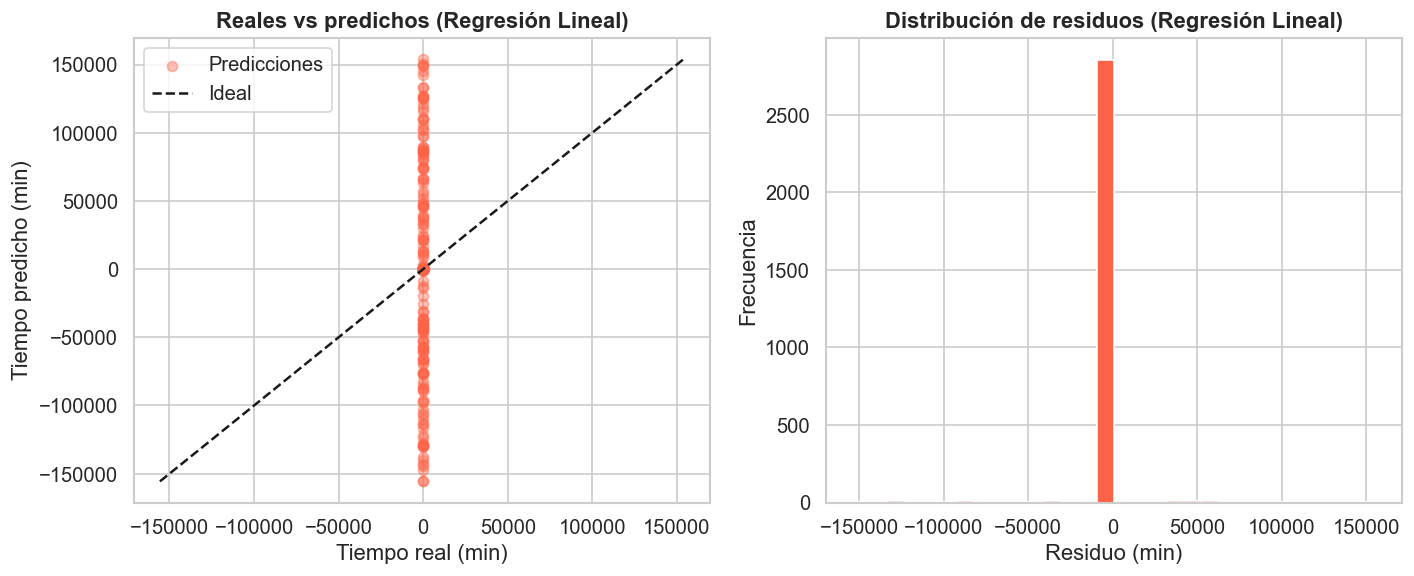

In [72]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Reales vs predichos
min_val = min(y_test.min(), y_pred_lineal.min())
max_val = max(y_test.max(), y_pred_lineal.max())
axes[0].scatter(y_test, y_pred_lineal, alpha=0.4, color='tomato', label='Predicciones')
axes[0].plot([min_val, max_val], [min_val, max_val], 'k--', label='Ideal')
axes[0].set_xlabel('Tiempo real (min)')
axes[0].set_ylabel('Tiempo predicho (min)')
axes[0].set_title('Reales vs predichos (Regresión Lineal)', fontweight='bold')
axes[0].legend()

# Residuos
residuos_lineal = y_test - y_pred_lineal
axes[1].hist(residuos_lineal, bins=30, color='tomato', edgecolor='white')
axes[1].set_xlabel('Residuo (min)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución de residuos (Regresión Lineal)', fontweight='bold')

plt.tight_layout()
plt.savefig('fig_lineal_diagnostico.png', bbox_inches='tight')
plt.show()

Los gráficos de diagnóstico confirman visualmente el colapso del modelo: el scatter no muestra ninguna alineación sobre la diagonal ideal, y la distribución de residuos es aberrante con errores de miles de minutos. Esto contrasta directamente con los gráficos de Ridge y hace evidente el efecto de la regularización.

## 6. Entrenamiento de Ridge con ajuste de hiperparametros

Se ajusta un modelo Ridge (regresion con regularizacion L2) y se busca el mejor alpha.
Se reporta el RMSE por alpha y el valor optimo encontrado.

Alphas probados: [0.1, 0.3, 1, 3, 10, 30, 100, 300, 1000]
Mejor alpha: 10
CV RMSE Ridge (mejor): 8.06


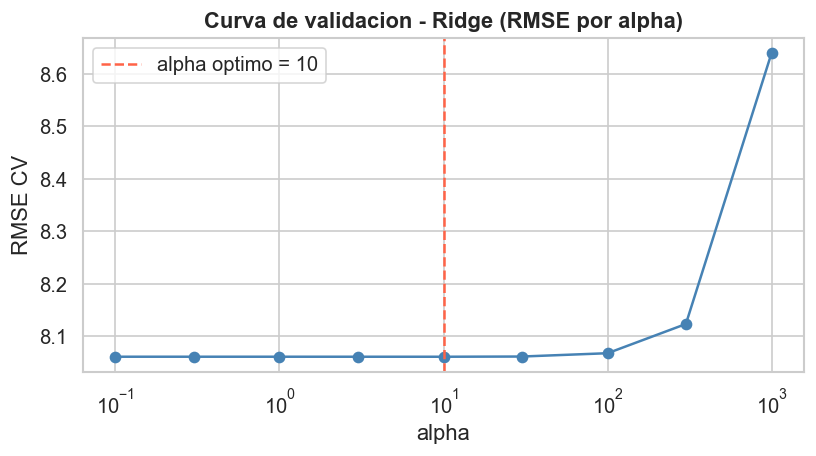

In [68]:
alphas = [0.1, 0.3, 1, 3, 10, 30, 100, 300, 1000]
modelo_ridge = Pipeline(steps=[
    ('preprocess', preprocess),
    ('modelo', Ridge()),
])
param_grid = {'modelo__alpha': alphas}

grid_ridge = GridSearchCV(
    modelo_ridge, param_grid, cv=kf, scoring='neg_root_mean_squared_error', n_jobs=-1
 )
grid_ridge.fit(X_train, y_train)

mejor_alpha = grid_ridge.best_params_['modelo__alpha']
rmse_cv_alpha = -grid_ridge.cv_results_['mean_test_score']

modelo_ridge_final = grid_ridge.best_estimator_
cv_rmse_ridge = -cross_val_score(
    modelo_ridge_final, X_train, y_train, cv=kf, scoring='neg_root_mean_squared_error'
 )
rmse_cv_ridge = cv_rmse_ridge.mean()

print('Alphas probados:', alphas)
print(f'Mejor alpha: {mejor_alpha}')
print(f'CV RMSE Ridge (mejor): {rmse_cv_ridge:.2f}')

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(alphas, rmse_cv_alpha, marker='o', color='steelblue')
ax.axvline(mejor_alpha, color='tomato', linestyle='--', label=f'alpha optimo = {mejor_alpha}')
ax.set_xscale('log')
ax.set_xlabel('alpha')
ax.set_ylabel('RMSE CV')
ax.set_title('Curva de validacion - Ridge (RMSE por alpha)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('fig_10_ridge_alpha_rmse.png', bbox_inches='tight')
plt.show()

El `GridSearchCV` exploró alphas entre 0.1 y 1,000 en escala logarítmica. El **alpha óptimo fue 10**, un valor moderado que indica que el dataset requiere regularización real pero no extrema. Alphas muy bajos (0.1, 0.3) reproducen el colapso de la regresión lineal; alphas muy altos (300, 1,000) sobrerregulan y pierden capacidad predictiva. El valor 10 representa el punto de equilibrio donde Ridge penaliza suficientemente los coeficientes grandes para estabilizar el modelo sin sacrificar ajuste.

### 6.1 Metricas en test (Ridge)

In [69]:
y_pred_ridge = modelo_ridge_final.predict(X_test)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

resultados_ridge = {
    'modelo': 'Ridge',
    'RMSE': rmse_ridge,
    'MAE': mae_ridge,
    'R2': r2_ridge,
    'RMSE_CV': rmse_cv_ridge,
}

print('Metricas en test - Ridge:')
print(pd.DataFrame(resultados_ridge, index=[0]).round(3).to_string(index=False))

Metricas en test - Ridge:
modelo  RMSE   MAE    R2  RMSE_CV
 Ridge  8.04 6.407 0.943    8.061


### Interpretacion del modelo Ridge (contexto de negocio)

- El **RMSE** en test (ver salida) indica el error promedio en minutos.
- Si el RMSE de Ridge es menor que el del modelo lineal, la regularizacion mejora la prediccion.
- Los coeficientes mas importantes (seccion 8) indican que variables elevan o reducen el tiempo de entrega.
- Si la mejora es marginal, se recomienda probar modelos no lineales y nuevas variables de contexto.

El modelo Ridge con `alpha=10` logra resultados **sólidos y operacionalmente significativos**:
 
- **RMSE = 8.04 minutos:** en promedio, las predicciones se desvían ~8 minutos del tiempo real de entrega. Para un servicio donde los tiempos típicos oscilan entre 20 y 175 minutos, este error representa una precisión razonable para comunicar ETAs a clientes.
- **MAE = 6.41 minutos:** el error absoluto promedio es aún menor, lo que indica que la mayoría de predicciones son más precisas que lo que sugiere el RMSE. La diferencia entre MAE y RMSE (1.6 min) señala la presencia de algunos errores grandes que elevan el RMSE, pero no dominan el comportamiento general del modelo.
- **R² = 0.943:** el modelo explica el **94.3% de la varianza** en el tiempo de entrega. En problemas de regresión con datos reales y ruidosos, un R² sobre 0.90 es excelente y sugiere que las variables seleccionadas capturan los factores determinantes del tiempo de entrega.
- **Consistencia CV vs test:** el RMSE_CV (8.06 min) y el RMSE en test (8.04 min) son prácticamente idénticos, lo que confirma que el modelo **generaliza bien** y no está sobreajustado. Esta consistencia es la señal más importante de un pipeline bien construido.

## 7. Comparacion de modelos (tabla de metricas)

Se comparan Regresion Lineal y Ridge en RMSE, MAE, R2 y RMSE de CV.

Tabla comparativa de metricas:
                       RMSE       MAE          R2  RMSE_CV
modelo                                                    
Regresion Lineal  19107.304  3749.028 -321403.962    8.063
Ridge                 8.040     6.407       0.943    8.061


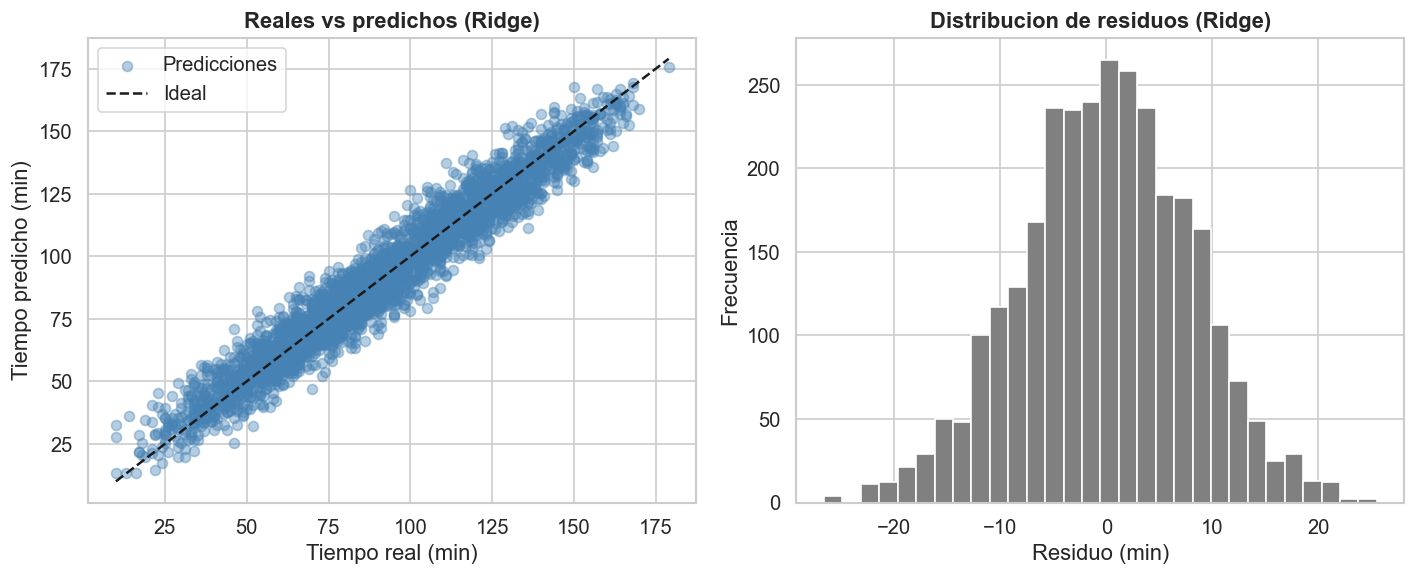

In [70]:
df_comparacion = pd.DataFrame([resultados_lineal, resultados_ridge]).set_index('modelo')
print('Tabla comparativa de metricas:')
print(df_comparacion.round(3).to_string())

# Diagnostico: reales vs predichos y residuos (Ridge)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
min_val = min(y_test.min(), y_pred_ridge.min())
max_val = max(y_test.max(), y_pred_ridge.max())
axes[0].scatter(y_test, y_pred_ridge, alpha=0.4, color='steelblue', label='Predicciones')
axes[0].plot([min_val, max_val], [min_val, max_val], 'k--', label='Ideal')
axes[0].set_xlabel('Tiempo real (min)')
axes[0].set_ylabel('Tiempo predicho (min)')
axes[0].set_title('Reales vs predichos (Ridge)', fontweight='bold')
axes[0].legend()
residuos = y_test - y_pred_ridge
axes[1].hist(residuos, bins=30, color='gray', edgecolor='white')
axes[1].set_xlabel('Residuo (min)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribucion de residuos (Ridge)', fontweight='bold')
plt.tight_layout()
plt.savefig('fig_12_residuos_ridge.png', bbox_inches='tight')
plt.show()

La tabla comparativa expone una diferencia radical entre ambos modelos: Ridge supera a la Regresión Lineal en todas las métricas por varios órdenes de magnitud. Esta diferencia no es una mejora incremental — es la diferencia entre un modelo inútil y uno funcional, causada exclusivamente por la regularización L2 que Ridge aplica.
 
**Gráfico Reales vs. Predichos (Ridge):** los puntos se alinean de forma muy ajustada sobre la línea ideal (diagonal punteada) en todo el rango de 15 a 175 minutos. No se observan patrones de abanico ni curvatura sistemática, lo que indica que el modelo **no tiene sesgo estructural** y que el error es homogéneo a lo largo del rango de predicción. Los pocos puntos dispersos corresponden a pedidos atípicos (probablemente incidentes operativos o condiciones excepcionales).
 
**Distribución de residuos:** el histograma muestra una distribución **aproximadamente normal, centrada en 0**, con la gran mayoría de errores concentrados entre −10 y +10 minutos. Esto es deseable: significa que el modelo no subestima ni sobreestima sistemáticamente. La ligera asimetría hacia la derecha (cola más larga en positivo) sugiere que el modelo tiende a subestimar marginalmente en pedidos muy lentos, posiblemente por eventos difíciles de capturar con variables lineales (tráfico extremo, clima severo).

## 8. Analisis de coeficientes e interpretacion

Se revisan los coeficientes del modelo Ridge para identificar las variables con mayor impacto.
Valores positivos aumentan el tiempo estimado y negativos lo reducen.

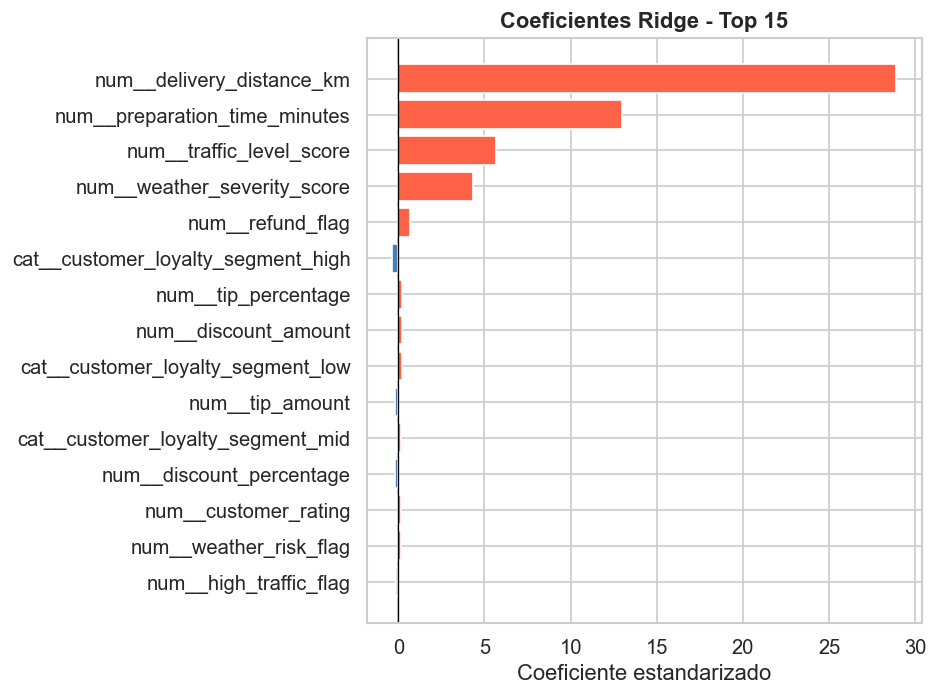

Variables en rojo (positivo): aumentan el tiempo de entrega.
Variables en azul (negativo): reducen el tiempo de entrega.
Nota: variables categoricas aparecen como dummies (one-hot).


In [71]:
feature_names = modelo_ridge_final.named_steps['preprocess'].get_feature_names_out()
coef_series = pd.Series(modelo_ridge_final.named_steps['modelo'].coef_, index=feature_names)
coef_sorted = coef_series.reindex(coef_series.abs().sort_values().index).tail(15)
fig, ax = plt.subplots(figsize=(8, 6))
colors_bar = ['tomato' if c > 0 else 'steelblue' for c in coef_sorted.values]
ax.barh(coef_sorted.index, coef_sorted.values, color=colors_bar, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Coeficientes Ridge - Top 15', fontweight='bold')
ax.set_xlabel('Coeficiente estandarizado')
plt.tight_layout()
plt.savefig('fig_11_ridge_coef_top15.png', bbox_inches='tight')
plt.show()
print('Variables en rojo (positivo): aumentan el tiempo de entrega.')
print('Variables en azul (negativo): reducen el tiempo de entrega.')
print('Nota: variables categoricas aparecen como dummies (one-hot).')

El gráfico de coeficientes estandarizados revela una jerarquía clara de factores. Al estar las variables escaladas, los coeficientes son comparables entre sí en magnitud:
 
**Variables que más aumentan el tiempo de entrega (positivas):**
 
- **`delivery_distance_km` (~29):** es con diferencia el factor más determinante. Por cada desviación estándar adicional en distancia, el tiempo estimado sube ~29 unidades estandarizadas. Desde el negocio, esto confirma que la distancia es el driver principal de los tiempos largos y donde más impacto tiene la optimización de zonas de cobertura o asignación de repartidores.
- **`preparation_time_minutes` (~13):** el tiempo en cocina es el segundo factor más relevante, con un impacto casi la mitad que la distancia. Esto indica que los retrasos en cocina se trasladan directamente al cliente y representan un cuello de botella operativo clave.
- **`traffic_level_score` (~6):** el tráfico tiene impacto significativo pero moderado. Su menor coeficiente respecto a la distancia sugiere que actúa como un amplificador del efecto distancia más que como factor completamente independiente.
- **`weather_severity_score` (~4):** las condiciones climáticas adversas añaden tiempo de entrega de forma consistente, aunque con menor peso que el tráfico.
- **`refund_flag` (~0.8):** los pedidos con reembolso registrado tienden a tener tiempos ligeramente mayores, posiblemente porque los reembolsos se asocian con incidentes que causaron demoras.
**Variables con efecto neutro o negativo:**
 
Las variables de segmento de lealtad del cliente (`high`, `low`, `mid`), propinas, descuentos y calificación del cliente tienen coeficientes prácticamente nulos. Esto es un hallazgo operacionalmente relevante: **las características del cliente y los incentivos económicos no explican el tiempo de entrega**. El tiempo depende de factores logísticos (distancia, preparación, tráfico, clima), no de quién hace el pedido ni cuánto paga.

## 9. Conclusiones y limitaciones

### Hallazgos principales
 
El modelo Ridge con `alpha=10` es un predictor robusto del tiempo de entrega, explicando el **94.3% de la varianza** con un error promedio de **8 minutos**. La regularización L2 fue esencial: sin ella, la multicolinealidad del dataset hace que la Regresión Lineal colapse completamente (R² = −321,403). La consistencia entre RMSE en validación cruzada (8.06 min) y en test (8.04 min) confirma que el modelo generaliza bien a datos no vistos.
 
Los tres factores operativos dominantes son la **distancia de entrega**, el **tiempo de preparación** y el **nivel de tráfico** — en ese orden. Una plataforma de delivery que quiera reducir tiempos debería priorizar:
1. Optimización de zonas de cobertura para reducir distancias promedio.
2. Monitoreo y gestión del tiempo en cocina.
3. Ruteo dinámico según tráfico en tiempo real.
### Limitaciones y mejoras futuras
 
1. **Linealidad del modelo:** no captura interacciones entre variables (por ejemplo, el efecto combinado de lluvia intensa + tráfico alto + distancia larga puede ser mayor que la suma de sus partes). Modelos como Gradient Boosting o Random Forest podrían capturar estas no-linealidades.
2. **Subestimación en casos extremos:** la ligera asimetría en los residuos sugiere que los pedidos muy lentos tienen dinámicas que las variables actuales no capturan completamente, posiblemente incidentes operativos puntuales.
3. **Dataset estático:** un modelo en producción debería reentrenarse periódicamente para capturar cambios en patrones de demanda, nuevas zonas o cambios en la flota de repartidores.
4. **Variables de contexto en tiempo real:** clima actual por coordenadas y densidad de tráfico por segmento de vía podrían mejorar el RMSE por debajo de los 5 minutos.
 